# Offline age-group SIR / SEIR / SIS comparison

 Two synthetic age groups and a fixed contact matrix avoid network-dependent
 population data. The independent reference uses the same binomial transition
 probabilities. Medians are visual comparisons; differences are not evidence of
 posterior bias. Sequential / parallel epydemix trial arrays are checked exactly.
 Requires the simulation integration PR. RNG, time grid, and group axes are explicit.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import multiprocessing as mp

import matplotlib.pyplot as plt
import numpy as np
from models.stochastic_seir_population import StochasticSEIRAgeGroups
from models.stochastic_sir_population import StochasticSIRAgeGroups
from models.stochastic_sis_population import StochasticSISAgeGroups

from epydemix.model.predefined_models import create_seir, create_sir, create_sis
from epydemix.population import Population

mp.set_start_method("spawn", force=True)
SEED, NSIM, WORKERS = 43, 32, 2
START, END = "2023-01-01", "2023-02-09"

sizes = np.array([5000, 5000])
contacts = np.array([[1.0, 0.2], [0.2, 1.0]])
population = Population()
population.add_population(sizes, Nk_names=["young", "old"])
population.add_contact_matrix(contacts)
I, E, R = np.array([50, 30]), np.array([20, 20]), np.zeros(2, dtype=int)
specifications = [
    (
        "SIR",
        create_sir(0.3, 0.1),
        StochasticSIRAgeGroups(sizes - I, I, R, 0.3, 0.1, contacts, sizes, 40),
    ),
    (
        "SEIR",
        create_seir(0.3, 0.2, 0.1),
        StochasticSEIRAgeGroups(
            sizes - I - E, E, I, R, 0.3, 0.2, 0.1, contacts, sizes, 40
        ),
    ),
    (
        "SIS",
        create_sis(0.3, 0.1),
        StochasticSISAgeGroups(sizes - I, I, 0.3, 0.1, contacts, sizes, 40),
    ),
]

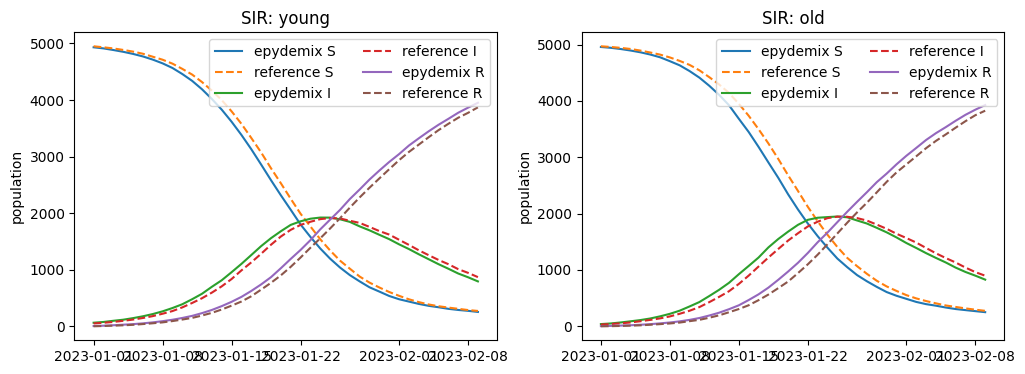

SIR sequential = parallel; full time/group grid


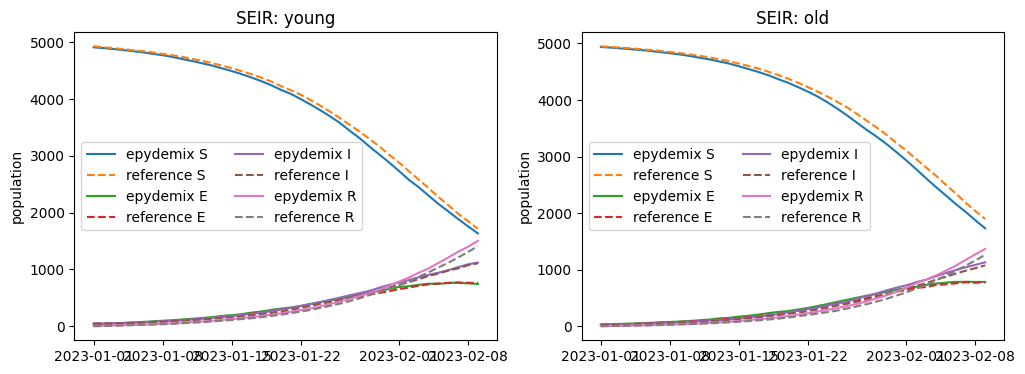

SEIR sequential = parallel; full time/group grid


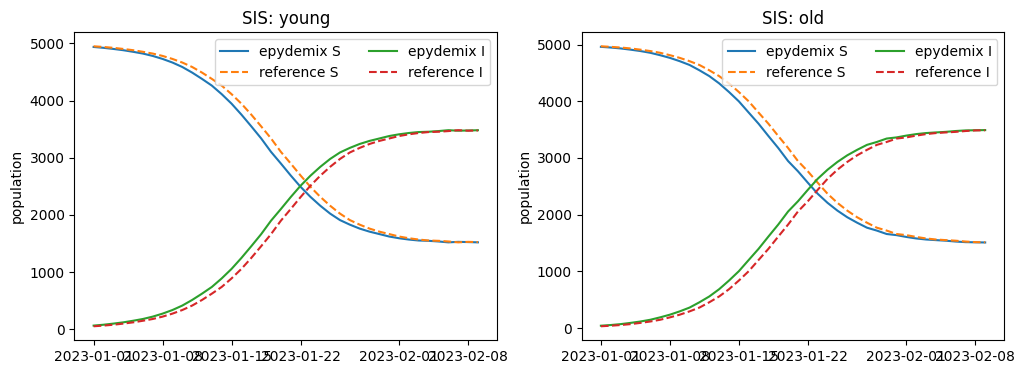

SIS sequential = parallel; full time/group grid


In [3]:
for name, model, reference in specifications:
    model.set_population(population)
    initial = {"Susceptible": sizes - I - (E if name == "SEIR" else 0), "Infected": I}
    if name != "SIS":
        initial["Recovered"] = R
    if name == "SEIR":
        initial["Exposed"] = E
    options = dict(
        start_date=START,
        end_date=END,
        initial_conditions_dict=initial,
        Nsim=NSIM,
        rng=SEED,
    )
    sequential = model.run_simulations(**options)
    parallel = model.run_simulations(**options, n_workers=WORKERS)
    for key, values in sequential.get_stacked_compartments().items():
        np.testing.assert_array_equal(values, parallel.get_stacked_compartments()[key])
    quantiles = reference.run_simulations(NSIM, quantiles=(0.5,), rng=SEED)
    median = parallel.get_quantiles_compartments(quantiles=[0.5])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for group, ax in enumerate(axes):
        for short, compartment in zip(
            "SEIR" if name == "SEIR" else "SIR" if name == "SIR" else "SI",
            model.compartments,
        ):
            assert quantiles[short][0.5].shape == (40, 2)
            ax.plot(
                median["date"],
                median[f"{compartment}_{population.Nk_names[group]}"],
                label=f"epydemix {short}",
            )
            ax.plot(
                median["date"],
                quantiles[short][0.5][:, group],
                linestyle="--",
                label=f"reference {short}",
            )
        ax.set(title=f"{name}: {population.Nk_names[group]}", ylabel="population")
        ax.legend(ncol=2)
    plt.show()
    plt.close(fig)
    print(name, "sequential = parallel; full time/group grid")